<a href="https://colab.research.google.com/github/gurovic/MLCourse/blob/main/110_linreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Линейная регрессия

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# !pip install scikit-learn

---

## 🟢 Базовый уровень (Основы)

### 1.1 Математическая формулировка  
**Уравнение регрессии:**  
$y = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n$  
**Функция потерь (MSE):**  
$MSE = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$

### 1.2 Простая реализация

In [2]:
# Пример данных
X = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 5, 8])

# Обучение модели
model = LinearRegression()
model.fit(X, y)

# Предсказание
y_pred = model.predict([[5]])
print(f"Прогноз: {y_pred[0]:.2f}")  # Ожидаем ~9.5

Прогноз: 9.50


### 1.3 Оценка качества

In [3]:
mse = mean_squared_error(y, model.predict(X))
print(f"MSE: {mse:.2f}")  # Должно быть < 1.0

MSE: 0.17


---

## 🟡 Продвинутый уровень (Градиентный спуск)

### 2.1 Ручная реализация MSE

In [4]:
def compute_mse(w0, w1, X, y):
    predictions = w0 + w1 * X
    return np.mean((y - predictions) ** 2)

### 2.2 Алгоритм градиентного спуска

In [5]:
def gradient_descent(X, y, lr=0.01, epochs=1000):
    w0, w1 = 0, 0
    n = len(X)

    for _ in range(epochs):
        y_pred = w0 + w1 * X
        grad_w0 = (-2/n) * np.sum(y - y_pred)
        grad_w1 = (-2/n) * np.sum(X * (y - y_pred))
        w0 -= lr * grad_w0
        w1 -= lr * grad_w1

    return w0, w1

# Применение
w0, w1 = gradient_descent(X.flatten(), y)
print(f"Уравнение: y = {w0:.2f} + {w1:.2f}x")

Уравнение: y = 0.03 + 1.89x


### 2.3 Визуализация процесса

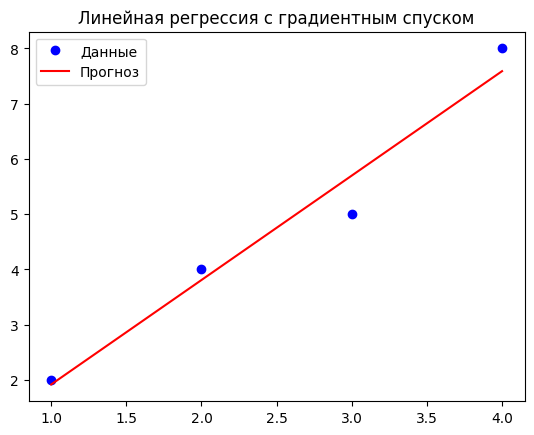

In [6]:
plt.plot(X, y, 'bo', label='Данные')
plt.plot(X, w0 + w1*X, 'r-', label='Прогноз')
plt.title('Линейная регрессия с градиентным спуском')
plt.legend()
plt.show()

---

## 🔴 Экспертный уровень (Продвинутые техники)

### 3.1 Стохастический градиентный спуск

In [7]:
def stochastic_gd(X, y, lr=0.01, epochs=100):
    w0, w1 = 0, 0
    n = len(X)

    for _ in range(epochs):
        for i in range(n):
            y_pred = w0 + w1 * X[i]
            grad_w0 = -2 * (y[i] - y_pred)
            grad_w1 = -2 * X[i] * (y[i] - y_pred)
            w0 -= lr * grad_w0
            w1 -= lr * grad_w1

    return w0, w1

### 3.2 Регуляризация (Ridge)

In [8]:
# Добавление L2-регуляризации к MSE
def ridge_mse(w0, w1, X, y, alpha=0.1):
    mse = compute_mse(w0, w1, X, y)
    return mse + alpha * (w0**2 + w1**2)

### 3.3 Адаптивные оптимизаторы (Adam)

In [9]:
# Реализация Adam Optimizer
def adam_optimizer(X, y, lr=0.01, beta1=0.9, beta2=0.999, epochs=1000):
    w0, w1 = 0, 0
    m_w0, v_w0 = 0, 0
    m_w1, v_w1 = 0, 0
    eps = 1e-8

    for t in range(1, epochs+1):
        y_pred = w0 + w1 * X
        grad_w0 = -2 * np.mean(y - y_pred)
        grad_w1 = -2 * np.mean(X * (y - y_pred))

        m_w0 = beta1 * m_w0 + (1 - beta1) * grad_w0
        m_w1 = beta1 * m_w1 + (1 - beta1) * grad_w1

        v_w0 = beta2 * v_w0 + (1 - beta2) * grad_w0**2
        v_w1 = beta2 * v_w1 + (1 - beta2) * grad_w1**2

        m_w0_hat = m_w0 / (1 - beta1**t)
        m_w1_hat = m_w1 / (1 - beta1**t)

        v_w0_hat = v_w0 / (1 - beta2**t)
        v_w1_hat = v_w1 / (1 - beta2**t)

        w0 -= lr * m_w0_hat / (np.sqrt(v_w0_hat) + eps)
        w1 -= lr * m_w1_hat / (np.sqrt(v_w1_hat) + eps)

    return w0, w1

---

## 📊 Чеклист по уровням

| Уровень | Навыки |
|---------|--------|
| 🟢 | Понимание MSE, использование LinearRegression |
| 🟡 | Реализация градиентного спуска, визуализация |
| 🔴 | Регуляризация, адаптивные оптимизаторы |

---

## ⚠️ Антипаттерны
1. **Не масштабирование данных** перед градиентным спуском
2. **Слишком большой learning rate** (расходимость)
3. **Игнорирование переобучения** без регуляризации
4. **Использование MSE** для данных с выбросами

---

## 🚀 Продвинутые советы
1. **Подбор learning rate:**
```python
for lr in [0.1, 0.01, 0.001]:
    w0, w1 = gradient_descent(X, y, lr=lr)
    mse = compute_mse(w0, w1, X, y)
    print(f"LR: {lr}, MSE: {mse:.2f}")
```

2. **Ранняя остановка:**
```python
best_mse = float('inf')
for epoch in range(epochs):
    # Обновление весов
    current_mse = compute_mse(w0, w1, X, y)
    if current_mse > best_mse:
        break
    best_mse = current_mse
```

3. **Полиномиальная регрессия:**
```python
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
```

---

## 📌 Тренировочные задания

### 🟢 Базовый уровень
1. Обучите модель на данных: X=[[1], [2], [3]], y=[1, 3, 5]. Предскажите y для X=4.
2. Рассчитайте MSE между истинными y=[2,4,6] и предсказанными [1.9, 3.8, 6.1].

### 🟡 Продвинутый уровень
1. Реализуйте градиентный спуск для датасета с 2 фичами.
2. Визуализируйте изменение MSE в процессе обучения.

### 🔴 Экспертный уровень
1. Реализуйте ElasticNet регуляризацию (L1+L2).
2. Сравните скорость сходимости Adam vs SGD.

---

In [10]:
# Пример решения 🟢 Задания 1
X = np.array([[1], [2], [3]])
y = np.array([1, 3, 5])
model = LinearRegression()
model.fit(X, y)
print(f"Прогноз для 4: {model.predict([[4]])[0]:.2f}")  # Должно быть ~7.0

Прогноз для 4: 7.00


---

## 📌 Заключение
Ключевые принципы:
1. **MSE чувствительна к выбросам** – используйте MAE при наличии аномалий
2. **Градиентный спуск требует масштабирования** (StandardScaler)
3. **Регуляризация** помогает бороться с переобучением
4. **Адаптивные методы** (Adam) часто эффективнее vanilla GD

Помните: линейная регрессия — базовый алгоритм, но требует глубокого понимания математики для правильного применения. Всегда проверяйте:
- Линейность связи (через scatter plots)
- Гомоскедастичность остатков
- Нормальность распределения ошибок